### 🧠 Método: Acción-Valor Incremental (ε-greedy)

**Idea principal:**  
El agente estima el valor promedio de cada acción `Q(a)` y lo actualiza de forma incremental.  
Usa una política ε-greedy: con probabilidad **ε** explora (elige una acción aleatoria)  
y con probabilidad **1-ε** explota (elige la mejor acción conocida).

**Ventajas:**
- Simple y fácil de implementar.  
- Control directo del equilibrio entre exploración y explotación mediante ε.

**Desventajas:**
- La exploración es aleatoria (sin dirección).  
- Requiere ajustar ε manualmente.


In [19]:
import numpy as np                      
import matplotlib.pyplot as plt    

In [20]:
GRID_SIZE = 5                           # Tamaño del tablero (5x5)
ACTIONS = {1: "up", 2: "down", 3: "left", 4: "right", 5: "stay"}  

In [21]:
# Inicializa posiciones aleatorias de la serpiente y la comida
def init_positions():
    head = np.random.randint(0, GRID_SIZE, size=2)   # posición inicial de la serpiente
    food = np.random.randint(0, GRID_SIZE, size=2)   # posición inicial de la comida
    while np.array_equal(head, food):                # evita que empiecen en el mismo lugar
        food = np.random.randint(0, GRID_SIZE, size=2)
    return head, food                                # retorna ambas posiciones


In [22]:
# Mueve la serpiente según la acción seleccionada
def move(head, action):
    if action == "up":       # arriba
        head = head + np.array([-1, 0])
    elif action == "down":   # abajo
        head = head + np.array([1, 0])
    elif action == "left":   # izquierda
        head = head + np.array([0, -1])
    elif action == "right":  # derecha
        head = head + np.array([0, 1])
    return head              # nueva posición de la serpiente

In [23]:
# Calcula la recompensa del movimiento
def get_reward(head, food):
    if np.array_equal(head, food):           # si llega a la comida
        return 1                             # recompensa positiva
    elif np.any(head < 0) or np.any(head >= GRID_SIZE):  # si choca con los bordes
        return -1                            # castigo negativo
    else:
        return 0                             # si se mueve sin chocar ni comer

In [24]:
partidas = 1000                             # Número de simulaciones totales
turnos = 100                                # Movimientos por partida
epsilons = [0, 0.01, 0.1]                   # Diferentes valores de epsilon (niveles de exploración)
recompensas_medias = np.zeros((len(epsilons), turnos))   # Matriz para promediar recompensas
acciones_optimas = np.zeros((len(epsilons), turnos))     # Matriz para medir acciones óptimas


In [25]:

for ej in range(partidas):                          # Simula 1000 partidas completas
    mejor_accion = 1                                # Acción "ideal" para comparar (comer)

    for i, e in enumerate(epsilons):                # Repite para cada valor de epsilon
        Q = {k: 0 for k in range(1,6)}              # Inicializa valores de acción-valor
        acciones = {k: 0 for k in range(1,6)}       # Contador de veces elegidas
        recompensas = {k: 0 for k in range(1,6)}    # Suma acumulada de recompensas

        head, food = init_positions()               # Nueva partida con posiciones aleatorias

        for exp in range(turnos):                   # Hasta 100 turnos por partida

            # --- Selección de acción ε-greedy ---
            if np.random.uniform(0,1) < e:          # Si el número aleatorio < ε → exploración
                a = np.random.randint(5) + 1        # Escoge acción aleatoria
            else:                                   # Si no, explota la mejor acción conocida
                maxQ = -100                         # Inicializa valor máximo bajo
                for j in range(1, 6):               # Revisa las 5 acciones
                    if Q[j] > maxQ:                 # Encuentra la acción con mayor valor Q
                        maxQ = Q[j]
                        a = j                       # Guarda la acción óptima

            # --- Ejecuta la acción seleccionada ---
            action_name = ACTIONS[a]                # Convierte el número en dirección
            new_head = move(head.copy(), action_name)  # Mueve la serpiente
            recompensa = get_reward(new_head, food) # Calcula la recompensa del movimiento
            head = new_head                         # Actualiza la posición

            # --- Actualización de valores Q (acción-valor) ---
            acciones[a] += 1                        # Incrementa el contador de esta acción
            recompensas[a] += recompensa             # Suma la recompensa obtenida
            Q[a] = recompensas[a] / acciones[a]      # Actualiza Q[a] como promedio incremental

            # --- Guarda métricas para análisis ---
            recompensas_medias[i][exp] += recompensa # Registra recompensa media
            acciones_optimas[i][exp] += (a == mejor_accion)  # Si coincide con la acción ideal

            # --- Si come o choca, reinicia partida ---
            if recompensa != 0:
                head, food = init_positions()
                
recompensas_medias /= partidas                     # Promedia las recompensas entre todas las partidas
acciones_optimas /= partidas                       # Promedia las veces que tomó la acción óptima



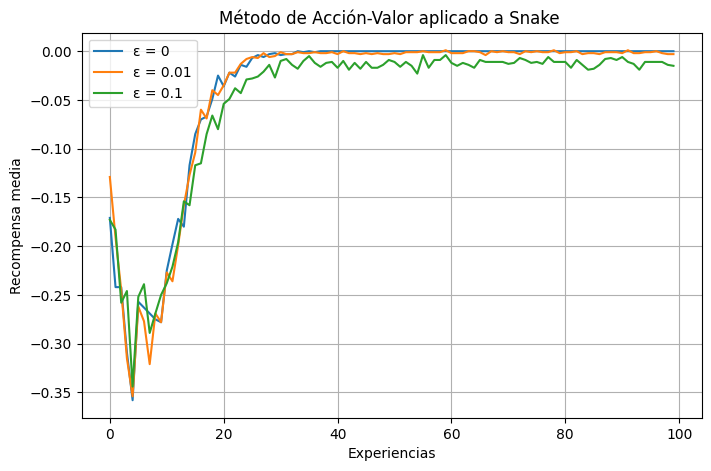

In [26]:

# --- GRAFICAR RECOMPENSA MEDIA ---
plt.figure(figsize=(8,5))                          # Tamaño de la figura
for i, e in enumerate(epsilons):                   # Una curva por valor de ε
    plt.plot(recompensas_medias[i], label=f'ε = {e}')  # Dibuja la recompensa promedio
plt.legend()                                       # Muestra la leyenda
plt.grid(True)                                     # Activa rejilla
plt.xlabel('Experiencias')                         # Eje X: número de turnos
plt.ylabel('Recompensa media')                     
plt.title('Método de Acción-Valor aplicado a Snake ')  
plt.show()                                         # Muestra la gráfica
